In [40]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
from matplotlib.gridspec import GridSpec
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import ticker
from scipy.integrate import solve_ivp
from numpy.fft import fft, ifft, fftfreq, fftshift, ifftshift
import os
import json


In [41]:
# Global parameter setting
np.random.seed(42)

# smoothness of prior distribution and initial condition
alpha = 1.5+1e-12
beta = 4
zeta = 6

# Fourier truncation for the prior
K_N = 5
# Fourier truncation for rho
rho_N = 20

# Space grid: Periodic [0, 1)
NX = 64            
L = 1.0
x_grid = np.linspace(0.0, L, NX, endpoint=False)
dx = L / NX

# Time grid: Closed [0, T]
NT = 63          
# number of data in the time-space grid
N_TOTAL = (NT + 1) * NX
T_FINAL = 0.1
dt = T_FINAL / NT
t_grid = np.linspace(0.0, T_FINAL, NT + 1)

# Scaling for prior distribution
SCALING_FACTOR = N_TOTAL ** ((alpha + 1 + beta) / (2*(alpha+1) + 2*beta + 1) - 1/2)


In [42]:
def initial_condition(x, zeta_=None):
    # Tent function: 4/3(1/2 + |x - 0.5|), centred at 0.5 on [0,1)
    phi = 4/3 * (0.5 + np.abs(x - 0.5))
    phi /= (np.sum(phi) * dx)
    return phi


def generate_coef_vec_for_prior(K_N, tau, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    k = np.arange(1, K_N+1)  # k = 1..K
    weights = tau * (2.0 / ((1 + k**2) ** ((alpha+1) / 2)))
    # weights = 2 * weights
    cov = np.diag(weights**2)
    
    return rng.multivariate_normal(np.zeros(K_N), cov)
   


def sample_negative_laplacian(sigma=4.0, tau=3, alpha=4, N=NX, M=1024):
    # Integer wavenumbers, not 2*pi*k
    k = np.fft.fftfreq(M, d=1/M)  # k = 0, 1, ..., M/2, -M/2+1, ..., -1
    
    # Eigenvalues of (-Delta + tau^2 I) in this convention
    A_eigs = k**2 + tau**2  # now tau=3 competes with k=1,2,3,...
    
    Cov_eigs = 1.0 / (A_eigs**alpha)
    z = np.random.randn(M) + 1j * np.random.randn(M)
    W_hat = np.sqrt(Cov_eigs) * z
    W_fine = np.fft.ifft(W_hat).real * M
    step = M // N
    W_coarse = W_fine[::step]
    W_coarse -= np.mean(W_coarse)
    W_coarse /= np.std(W_coarse)  # unit variance
    W_coarse *= sigma
    return W_coarse



In [43]:
def forward_map_full_history_symmetric(zeta_=None):
    """
    De-aliased pseudo-spectral IMEX Euler for:
        ∂t ρ = ∂xx ρ + ∂x(ρ * (W' * ρ))
    with periodic BC on [0,1).
    - W symmetric => only cos_coeff used.
    """
    if zeta_ is None:
        zeta_ = zeta

    # base wavenumbers
    k_freq = fftfreq(NX, d=dx)
    k_wav  = 2 * np.pi * k_freq
    ik     = 1j * k_wav
    k2     = k_wav**2

    # IMEX diffusion operator (implicit)
    nu = 1  # was implicitly 1.0, make nu smaller to reduce effect of diffusion. Original paper uses nu=1, so keep it.
    diffusion_operator = 1.0 / (1.0 + dt * nu * k2)

    # build W'_hat in base grid directly in Fourier
    W_x = sample_negative_laplacian(tau=3, alpha=4, N=NX)
    Wprime_hat = ik * fft(W_x)  # W' in Fourier = ik * W_hat

    # init
    rho = initial_condition(x_grid, zeta_)
    rho_history = np.zeros((NT + 1, NX), dtype=float)
    rho_history[0, :] = rho

    rho_hat = fft(rho)

    for n in range(NT):
        # u = (W' * rho)  (discrete convolution consistent with FFT conventions)
        # NOTE: multiply by dx to approximate integral convolution on [0,1)
        u = np.real(ifft(Wprime_hat * rho_hat)) * dx

        rho_x = np.real(ifft(rho_hat))
        flux = rho_x * u

        # interaction term: ∂x(flux)
        interaction_hat = ik * fft(flux)

        # IMEX Euler update
        rho_hat = (rho_hat + dt * interaction_hat) * diffusion_operator

        rho_next = np.real(ifft(rho_hat))

        rho_next = np.maximum(rho_next, 0.0)
        rho_next /= (np.sum(rho_next) * dx)

        rho_history[n + 1, :] = rho_next
        rho_hat = fft(rho_next)

    return rho_history


In [44]:
def generate_dataset(n_samples, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    
    inputs = []   # W evaluated on x_grid, shape (n_samples, NX)
    outputs = []  # rho_history, shape (n_samples, NT+1, NX)
    
    for _ in range(n_samples):
        W_vals = sample_negative_laplacian(sigma=4.0, tau=3, alpha=4, N=NX)
        rho_hist = forward_map_full_history_symmetric(W_vals)
        inputs.append(W_vals)
        outputs.append(rho_hist)
    
    return np.array(inputs), np.array(outputs)

def plot_sample(sample):
    """
    Visualise one sample from generate_dataset(1).
    sample = (inputs, outputs) where
        inputs:  shape (1, NX)        — W(x)
        outputs: shape (1, NT+1, NX)  — rho(x, t)
    """
    W = sample[0][0]          # shape (NX,)
    rho = sample[1][0]        # shape (NT+1, NX)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # --- Panel 1: interaction potential W(x) ---
    ax = axes[0]
    ax.plot(x_grid, W, color='steelblue')
    ax.set_title('Interaction potential $W(x)$')
    ax.set_xlabel('$x$')
    ax.set_ylabel('$W(x)$')

    # --- Panel 2: rho(x,t) as a heatmap ---
    ax = axes[1]
    im = ax.imshow(
        rho.T,                          # shape (NX, NT+1) so x on y-axis
        aspect='auto',
        origin='lower',
        extent=[0, T_FINAL, 0, L],
        cmap='viridis'
    )
    plt.colorbar(im, ax=ax)
    ax.set_title(r'Density $\rho(x,t)$')
    ax.set_xlabel('$t$')
    ax.set_ylabel('$x$')

    # --- Panel 3: rho(x,t) at a few selected times ---
    ax = axes[2]
    n_lines = 5
    time_indices = np.linspace(0, NT, n_lines, dtype=int)
    colors = plt.cm.plasma(np.linspace(0, 1, n_lines))
    for i, idx in enumerate(time_indices):
        ax.plot(x_grid, rho[idx], color=colors[i],
                label=f'$t={t_grid[idx]:.3f}$')
    ax.set_title(r'$\rho(x,t)$ at selected times')
    ax.set_xlabel('$x$')
    ax.set_ylabel(r'$\rho$')
    ax.legend(fontsize=8)

    plt.tight_layout()
    plt.show()

(1, 64)
(1, 64, 64)


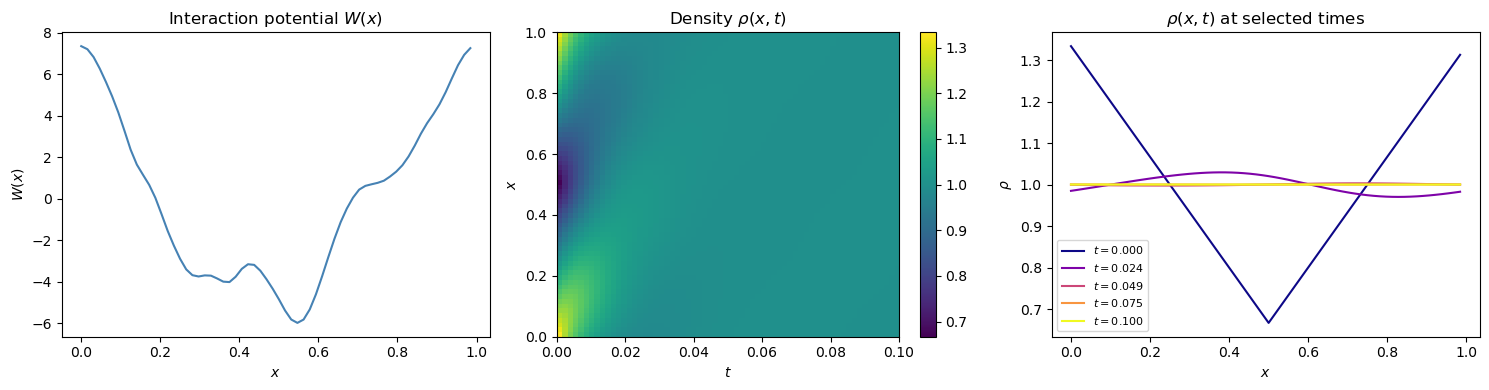

(64, 64)


In [45]:
sample = generate_dataset(1)
print(sample[0].shape)
print(sample[1].shape)
plot_sample(sample)
print(sample[1][0].shape)

from torch.utils.data import Dataset
from torch.utils.data import DataLoader
print(DataLoader(sample[0]))

In [46]:
# ── Global: finest resolution ──────────────────────────────────────────────
RESOLUTIONS = [4, 8, 16, 32, 64, 128]
NX_FINE = 128        # generate at this resolution
NT_FINE = 127        # NT_FINE + 1 must be divisible by all resolutions
T_FINAL = 0.1

def forward_map_full_history_symmetric(W_x, NX=NX_FINE, NT=NT_FINE, zeta_=None):
    L = 1.0
    dx = L / NX
    dt = T_FINAL / NT
    x_grid = np.linspace(0.0, L, NX, endpoint=False)

    k_freq = fftfreq(NX, d=dx)
    k_wav  = 2 * np.pi * k_freq
    ik     = 1j * k_wav
    k2     = k_wav ** 2

    diffusion_operator = 1.0 / (1.0 + dt * k2)

    Wprime_hat = ik * fft(W_x)

    rho = initial_condition(x_grid)
    rho_history = np.zeros((NT + 1, NX), dtype=float)
    rho_history[0, :] = rho
    rho_hat = fft(rho)

    for n in range(NT):
        u = np.real(ifft(Wprime_hat * rho_hat)) * dx
        rho_x = np.real(ifft(rho_hat))
        flux = rho_x * u
        interaction_hat = ik * fft(flux)
        rho_hat = (rho_hat + dt * interaction_hat) * diffusion_operator
        rho_next = np.real(ifft(rho_hat))
        rho_next = np.maximum(rho_next, 0.0)
        rho_next /= (np.sum(rho_next) * dx)
        rho_history[n + 1, :] = rho_next
        rho_hat = fft(rho_next)

    return rho_history


def generate_dataset_multires(n_samples, sigma=4, resolutions=RESOLUTIONS, rng=None):
    """
    Generate n_samples at the finest resolution (NX_FINE x NT_FINE+1),
    then downsample to each resolution in resolutions.

    Returns a dict keyed by resolution N:
        dataset[N] = (W_N, rho_N)
        W_N   shape: (n_samples, N)          — W subsampled to N spatial points
        rho_N shape: (n_samples, N, N)       — rho subsampled to N x N spacetime grid
    """
    if rng is None:
        rng = np.random.default_rng()

    # Generate everything at fine resolution
    W_fine_all   = []   # (n_samples, NX_FINE)
    rho_fine_all = []   # (n_samples, NT_FINE+1, NX_FINE)

    for _ in range(n_samples):
        W_fine = sample_negative_laplacian(
            sigma=sigma, tau=3, alpha=4, N=NX_FINE
        )
        rho_fine = forward_map_full_history_symmetric(W_fine, NX=NX_FINE, NT=NT_FINE)
        W_fine_all.append(W_fine)
        rho_fine_all.append(rho_fine)

    W_fine_all   = np.array(W_fine_all)    # (n_samples, NX_FINE)
    rho_fine_all = np.array(rho_fine_all)  # (n_samples, NT_FINE+1, NX_FINE)

    # Downsample to each resolution
    dataset = {}
    for N in resolutions:
        assert NX_FINE % N == 0, f"NX_FINE={NX_FINE} not divisible by N={N}"
        assert (NT_FINE + 1) % N == 0, f"NT_FINE+1={NT_FINE+1} not divisible by N={N}"

        sx = NX_FINE // N   # spatial stride
        st = (NT_FINE + 1) // N  # temporal stride

        W_N   = W_fine_all[:, ::sx]                   # (n_samples, N)
        rho_N = rho_fine_all[:, ::st, :][:, :, ::sx]  # (n_samples, N, N)

        dataset[N] = (W_N, rho_N)

    return dataset


def get_resolution(dataset, N):
    """Access dataset at resolution N. Returns (W, rho) arrays."""
    return dataset[N]

In [47]:
def save_dataset(dataset, path="mckean_vlasov_dataset.npz"):
    """Save multires dataset to a single .npz file."""
    arrays = {}
    for N, (W, rho) in dataset.items():
        arrays[f"W_{N}"]   = W
        arrays[f"rho_{N}"] = rho
    np.savez(path, **arrays)
    print(f"Saved dataset to {path}")


def load_dataset_mckean_vlasov(path="mckean_vlasov_dataset.npz"):
    """Load multires dataset from .npz file, returning same dict format."""
    data = np.load(path)
    dataset = {}
    # infer resolutions from keys
    resolutions = sorted(set(
        int(k.split("_")[1]) for k in data.files
    ))
    for N in resolutions:
        dataset[N] = (data[f"W_{N}"], data[f"rho_{N}"])
    return dataset

In [48]:
# --- generate once and save ---
dataset = generate_dataset_multires(n_samples=5000)
save_dataset(dataset, "mckean_vlasov_dataset.npz")

Saved dataset to mckean_vlasov_dataset.npz


In [49]:
# --- in any future session, just load and continue as-is ---
dataset = load_dataset_mckean_vlasov("mckean_vlasov_dataset.npz")

W_64, rho_64 = get_resolution(dataset, 64)
W_8,  rho_8  = get_resolution(dataset, 8)

In [50]:
print(len(dataset[4][0]))

5000
